In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA 
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 50    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 3     # Features dimension

# Optimization
MAXITER    = 200     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = False 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────
REUPLOAD_SHOTS = 2048


In [3]:
if USE_NOISE:
    print("Construction du simulateur BRUITÉ...")
    nm = NoiseModel()
    # Erreur sur les portes simples (1 qubit)
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    # Erreur sur l'intrication (2 qubits) - on met souvent 5x plus
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    
    # On crée le backend (ton ancien AerSimulator)
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    # On l'enveloppe pour le rendre compatible VQC
    sampler = Sampler(backend)
else:
    print("-> Mode IDÉAL")
    sampler = Sampler(AerSimulator())

-> Mode IDÉAL


In [4]:
def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Génération de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))    
    # Le rayon par défaut est choisi pour équilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3) 
        
    # Calcul de la norme euclidienne au carré
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    
    return X, y, radius



In [5]:
X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape, y_train.shape)

(40, 3) (40,)


## VQC

In [66]:
iteration = 0
def callback(*args):
    global iteration
    iteration += 1 
    print(f"Iteration {iteration}")

In [67]:
feature_map = zz_feature_map(feature_dimension=N_DIM, reps=2)
ansatz = real_amplitudes(num_qubits=N_DIM, reps=2)

vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, callback=callback)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


## Training

In [68]:
print(f"Entraînement sur une {N_DIM}-sphère...")
vqc.fit(X_train, y_train )

Entraînement sur une 3-sphère...


## VQC Results 

In [69]:
accuracy = vqc.score(X_test, y_test)
y_pred = vqc.predict(X_test)
print(f"Précision sur le test: {accuracy*100} %")

Précision sur le test: 75.0 %


### VQC circuit

--- FEATURE MAP ---


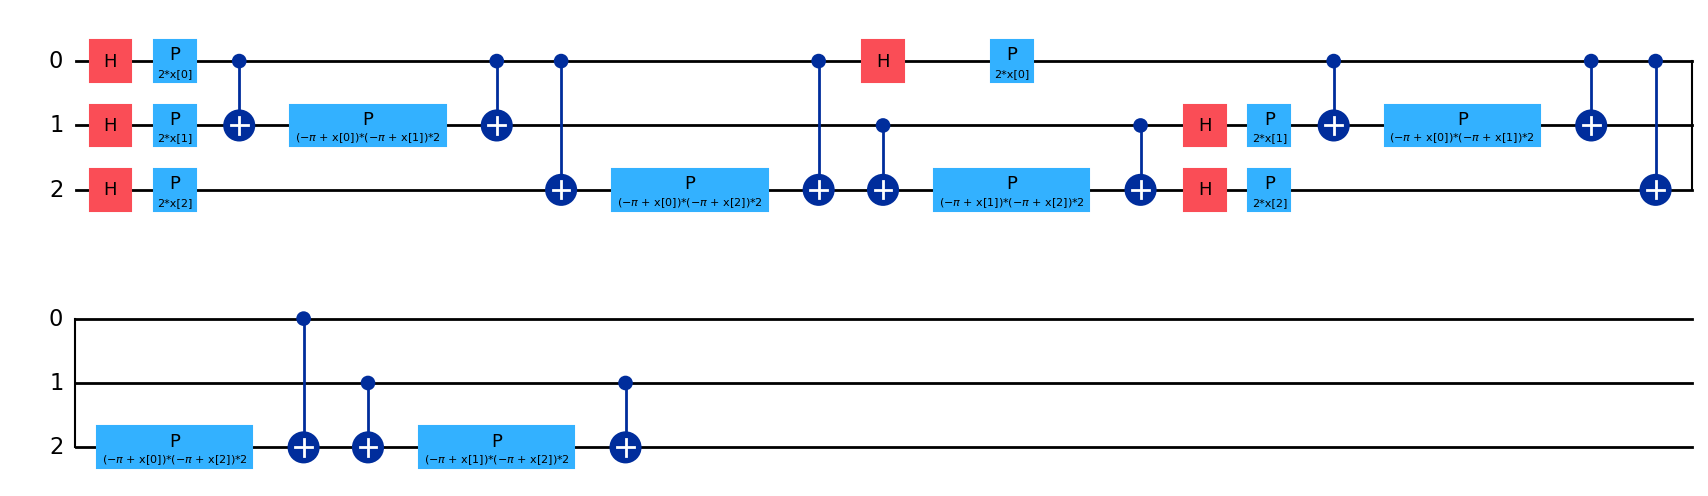

In [70]:
# 1. Visualiser comment les données N-dim sont encodées
print("--- FEATURE MAP ---")
vqc.feature_map.draw('mpl')



--- ANSATZ ---


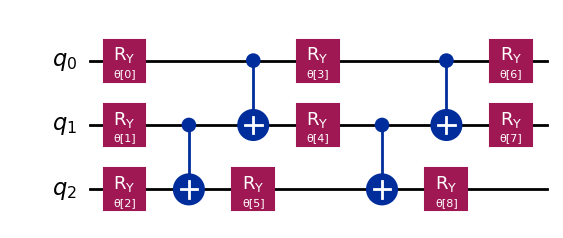

In [71]:
# 2. Visualiser la structure d'entraînement (les couches de rotation et CNOT)
print("--- ANSATZ ---")
vqc.ansatz.draw('mpl')

### Visualisation si dim=2 ou 3 

In [72]:
def plot_2d() : 
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    plt.scatter(pred0[:,0],pred0[:,1], color = 'red', label='pred0')
    plt.scatter(pred1[:,0],pred1[:,1], color = 'blue', label='pred1')


    circle_rad = np.sqrt(N_DIM/3) # rayon par défaut, à modifier si le rayon est changé
    circle = plt.Circle((0, 0), circle_rad, color='black', fill=False, 
                        linestyle='--', linewidth=2, label='Frontière réelle')
    plt.gca().add_artist(circle)

    # Configuration du graphique
    plt.title(f"Visualisation des performances ({accuracy*100}%)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_3d() :
    from mpl_toolkits.mplot3d import Axes3D
 
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Masques pour séparer les résultats
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    ax.scatter(pred0[:,0],pred0[:,1],pred0[:,2], color = 'red', label='pred0')
    ax.scatter(pred1[:,0],pred1[:,1],pred1[:,2], color = 'blue', label='pred1')
    

    # Dessiner l'enveloppe de la sphère théorique (Wireframe)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="black", alpha=0.1, linewidths=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Visualisation 3D : Accuracy {accuracy*100}%")
    ax.legend()
    plt.show()

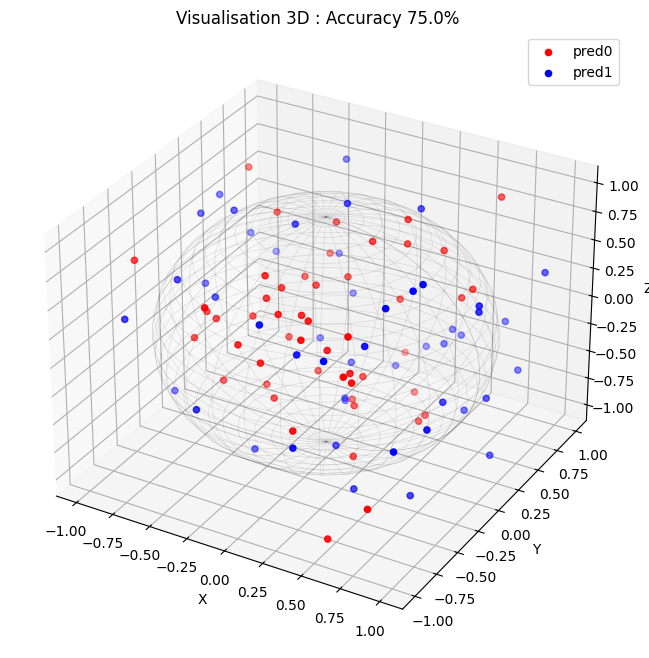

In [73]:

if N_DIM == 2 : 
    plot_2d()
    
elif N_DIM == 3 : 
    plot_3d()
    
    

## Re-uploading baseline (1 qubit, seulement pour la 3-sphère)

On garde le VQC actuel, puis on ajoute un second entraînement inspiré du notebook `circuit.ipynb`. Cette seconde partie n'est exécutée que si `N_DIM == 3`, car on veut tester l'idée qu'un seul qubit peut suffire avec du re-uploading.

In [6]:
from scipy.optimize import minimize
from qiskit_aer import StatevectorSimulator


In [7]:
# Hyperparamètres du modèle re-uploading
RC_REUPLOAD_VALUES = [2, 4, 6, 8, 10, 12, 14]
MAXITER_REUPLOAD = 150
USE_REUPLOAD = (N_DIM == 3)

print(f"USE_REUPLOAD = {USE_REUPLOAD}")
print(f"RC_REUPLOAD_VALUES = {RC_REUPLOAD_VALUES}")
if not USE_REUPLOAD:
    print("Le bloc re-uploading ci-dessous est prévu pour N_DIM = 3.")

USE_REUPLOAD = True
RC_REUPLOAD_VALUES = [2, 4, 6, 8, 10, 12, 14]


In [8]:
def U_su2_reupload(qc, theta_block, omega_block, x, qubit=0):
    """
    Une couche de type U(theta + omega * x) sur un seul qubit.
    Pour N_DIM=3, on injecte directement les 3 coordonnées.
    """
    qc.u(
        theta_block[0] + omega_block[0] * x[0],
        theta_block[1] + omega_block[1] * x[1],
        theta_block[2] + omega_block[2] * x[2],
        qubit
    )

def create_reupload_circuit(x, theta, omega, rc_reupload, measure=False):
    qc = QuantumCircuit(1)
    for r in range(rc_reupload):
        qc.h(0)
        U_su2_reupload(qc, theta[r], omega[r], x, qubit=0)
    if measure:
        qc.measure_all()
    return qc

def get_reupload_probs_batch(circuits, shots=REUPLOAD_SHOTS):
    """
    - Si USE_NOISE = True : exécute les circuits mesurés sur AerSimulator bruité.
    - Sinon : utilise StatevectorSimulator pour obtenir les probabilités exactes.
    """
    probs = []

    if USE_NOISE:
        measured_circuits = []
        for qc in circuits:
            qc_m = qc.copy()
            if qc_m.num_clbits == 0:
                qc_m.measure_all()
            measured_circuits.append(qc_m)

        transpiled_circuits = transpile(measured_circuits, backend)
        result = backend.run(transpiled_circuits, shots=shots).result()

        for qc_t in transpiled_circuits:
            counts = result.get_counts(qc_t)
            p0 = counts.get('0', 0) / shots
            p1 = counts.get('1', 0) / shots
            probs.append((p0, p1))
    else:
        sim = StatevectorSimulator()
        for qc in circuits:
            sv = sim.run(qc).result().get_statevector()
            p0 = float(np.abs(sv[0])**2)
            p1 = float(np.abs(sv[1])**2)
            probs.append((p0, p1))

    return probs

def reupload_cost_weighted(params, X, y, rc_reupload):
    """
    Même esprit que dans circuit.ipynb :
    - theta : paramètres "de traitement"
    - omega : poids qui multiplient les features avant réinjection
    - alphas : poids de classe pour équilibrer le coût
    """
    theta = params[:3 * rc_reupload].reshape(rc_reupload, 3)
    omega = params[3 * rc_reupload:6 * rc_reupload].reshape(rc_reupload, 3)
    alphas = params[6 * rc_reupload:]  # alpha_0, alpha_1

    circuits = [create_reupload_circuit(x, theta, omega, rc_reupload, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        weight = alphas[y_target] ** 2
        total_cost += weight * ((p0 - y_expected[0])**2 + (p1 - y_expected[1])**2)

    return 0.5 * total_cost / len(X)

def unpack_reupload_params(params, rc_reupload):
    theta = params[:3 * rc_reupload].reshape(rc_reupload, 3)
    omega = params[3 * rc_reupload:6 * rc_reupload].reshape(rc_reupload, 3)
    alphas = params[6 * rc_reupload:]
    return theta, omega, alphas

def optimize_reupload_parameters(X, y, rc_reupload):
    rng = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=6 * rc_reupload + 2)

    reupload_cost_history = []

    def objective(params):
        cost = reupload_cost_weighted(params, X, y, rc_reupload)
        reupload_cost_history.append(cost)
        print(f"[RC={rc_reupload}] Iteration {len(reupload_cost_history):3d} | cost = {cost:.6f}")
        return cost

    res = minimize(
        objective,
        init,
        method="COBYLA",
        options={"maxiter": MAXITER_REUPLOAD}
    )

    theta_opt, omega_opt, alphas_opt = unpack_reupload_params(res.x, rc_reupload)
    return res, theta_opt, omega_opt, alphas_opt, reupload_cost_history

def predict_reupload_batch(X, theta, omega, rc_reupload):
    circuits = [create_reupload_circuit(x, theta, omega, rc_reupload, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)
    return np.array([0 if p0 >= p1 else 1 for p0, p1 in probs])

def evaluate_reupload(X, y, theta, omega, rc_reupload):
    y_pred = predict_reupload_batch(X, theta, omega, rc_reupload)
    accuracy = np.mean(y_pred == y)
    return accuracy, y_pred

In [9]:
# Cette cellule est volontairement laissée vide.
# Les fonctions re-uploading paramétrées par rc_reupload sont définies dans la cellule précédente.
print("Fonctions re-uploading déjà définies (version paramétrée par RC_REUPLOAD).")

Fonctions re-uploading déjà définies (version paramétrée par RC_REUPLOAD).


In [10]:
if USE_REUPLOAD:
    print("Balayage re-uploading (1 qubit) selon RC_REUPLOAD...")

    reupload_results = {
        "rc_values": [],
        "accuracies": [],
        "models": [],
        "cost_histories": []
    }

    for rc in RC_REUPLOAD_VALUES:
        print(f"\n=== Entraînement re-uploading avec RC_REUPLOAD={rc} ===")
        reupload_res, theta_re, omega_re, alpha_re, reupload_cost_history = optimize_reupload_parameters(X_train, y_train, rc)
        reupload_accuracy, y_pred_reupload = evaluate_reupload(X_test, y_test, theta_re, omega_re, rc)

        reupload_results["rc_values"].append(rc)
        reupload_results["accuracies"].append(float(reupload_accuracy))
        reupload_results["models"].append((theta_re, omega_re, alpha_re, reupload_res))
        reupload_results["cost_histories"].append(reupload_cost_history)

        print(f"Précision test re-uploading (RC={rc}) : {100 * reupload_accuracy:.2f}%")

    best_idx = int(np.argmax(reupload_results["accuracies"]))
    best_rc = reupload_results["rc_values"][best_idx]
    theta_re, omega_re, alpha_re, reupload_res = reupload_results["models"][best_idx]
    reupload_cost_history = reupload_results["cost_histories"][best_idx]
    reupload_accuracy = reupload_results["accuracies"][best_idx]
    y_pred_reupload = predict_reupload_batch(X_test, theta_re, omega_re, best_rc)

    print(f"\nMeilleur RC_REUPLOAD = {best_rc}")
    print(f"Meilleure précision test re-uploading : {100 * reupload_accuracy:.2f}%")
else:
    print("Bloc non exécuté car N_DIM != 3")

Balayage re-uploading (1 qubit) selon RC_REUPLOAD...

=== Entraînement re-uploading avec RC_REUPLOAD=2 ===
[RC=2] Iteration   1 | cost = 0.518312
[RC=2] Iteration   2 | cost = 0.505277
[RC=2] Iteration   3 | cost = 0.471175
[RC=2] Iteration   4 | cost = 0.872904
[RC=2] Iteration   5 | cost = 0.633674
[RC=2] Iteration   6 | cost = 0.471175
[RC=2] Iteration   7 | cost = 0.696636
[RC=2] Iteration   8 | cost = 0.440677
[RC=2] Iteration   9 | cost = 0.450860
[RC=2] Iteration  10 | cost = 0.557747
[RC=2] Iteration  11 | cost = 0.539953
[RC=2] Iteration  12 | cost = 0.440677
[RC=2] Iteration  13 | cost = 0.459192
[RC=2] Iteration  14 | cost = 0.272333
[RC=2] Iteration  15 | cost = 0.654785
[RC=2] Iteration  16 | cost = 0.046612
[RC=2] Iteration  17 | cost = 0.068470
[RC=2] Iteration  18 | cost = 0.064981
[RC=2] Iteration  19 | cost = 0.063250
[RC=2] Iteration  20 | cost = 0.075868
[RC=2] Iteration  21 | cost = 0.068119
[RC=2] Iteration  22 | cost = 0.046612
[RC=2] Iteration  23 | cost = 0.066

Circuit re-uploading appris (meilleur RC=8) :


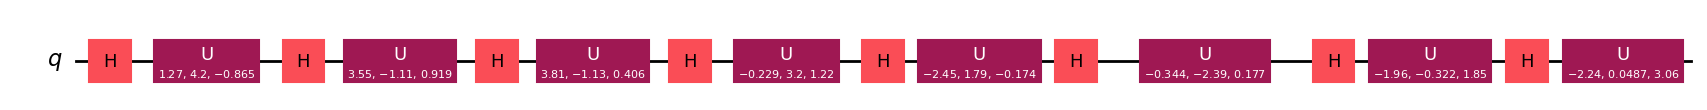

In [11]:
if USE_REUPLOAD:
    print(f"Circuit re-uploading appris (meilleur RC={best_rc}) :")
    qc_reupload = create_reupload_circuit(X_train[0], theta_re, omega_re, best_rc, measure=False)
    display(qc_reupload.draw("mpl"))

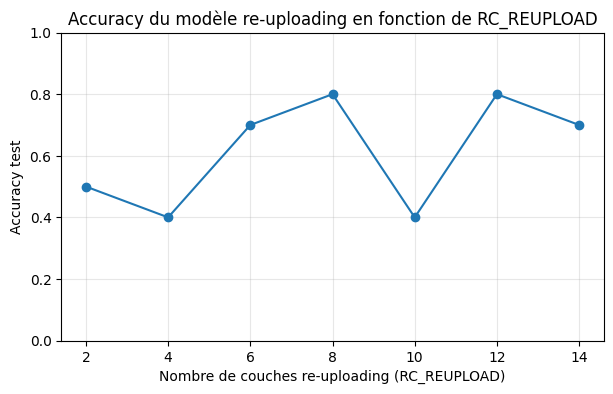

In [12]:
if USE_REUPLOAD:
    plt.figure(figsize=(7, 4))
    plt.plot(reupload_results["rc_values"], reupload_results["accuracies"], marker="o")
    plt.xlabel("Nombre de couches re-uploading (RC_REUPLOAD)")
    plt.ylabel("Accuracy test")
    plt.title("Accuracy du modèle re-uploading en fonction de RC_REUPLOAD")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

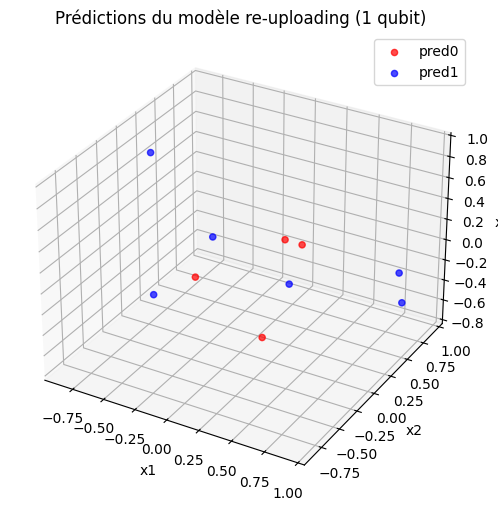

In [13]:
def plot_3d_reupload():
    pred1 = X_test[y_pred_reupload == 1]
    pred0 = X_test[y_pred_reupload == 0]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(pred0[:, 0], pred0[:, 1], pred0[:, 2], color='red', label='pred0', alpha=0.7)
    ax.scatter(pred1[:, 0], pred1[:, 1], pred1[:, 2], color='blue', label='pred1', alpha=0.7)

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.set_title('Prédictions du modèle re-uploading (1 qubit)')
    ax.legend()
    plt.show()

if USE_REUPLOAD and N_DIM == 3:
    plot_3d_reupload()

In [82]:
if USE_REUPLOAD:
    print("=== Comparaison rapide ===")
    print(f"VQC classique  ({N_DIM} qubits) : {accuracy * 100:.2f}%")
    print(f"Re-uploading   (1 qubit)  : {reupload_accuracy * 100:.2f}%")

=== Comparaison rapide ===
VQC classique  (3 qubits) : 75.00%
Re-uploading   (1 qubit)  : 61.00%


## AdaBoost sur le re-uploading (nombre de classifieurs variable)

On fixe la profondeur du weak learner au meilleur `RC_REUPLOAD` trouvé (`best_rc`),
puis on fait varier le nombre de classifieurs dans AdaBoost pour tracer l'accuracy finale.

In [ ]:
N_ESTIMATORS_VALUES = [1, 2, 3, 4, 5, 6, 8, 10]
MAXITER_WEAK_REUPLOAD = MAXITER_REUPLOAD

def reupload_cost_weighted_samples(params, X, y, sample_weights, rc_reupload):
    theta = params[:3 * rc_reupload].reshape(rc_reupload, 3)
    omega = params[3 * rc_reupload:].reshape(rc_reupload, 3)

    circuits = [create_reupload_circuit(x, theta, omega, rc_reupload, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        total_cost += sample_weights[i] * ((p0 - y_expected[0])**2 + (p1 - y_expected[1])**2)

    return 0.5 * total_cost / np.sum(sample_weights)

def optimize_reupload_weak_learner(X, y, sample_weights, rc_reupload, seed):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * rc_reupload)

    res = minimize(
        reupload_cost_weighted_samples,
        init,
        args=(X, y, sample_weights, rc_reupload),
        method="COBYLA",
        options={"maxiter": MAXITER_WEAK_REUPLOAD},
    )

    theta = res.x[:3 * rc_reupload].reshape(rc_reupload, 3)
    omega = res.x[3 * rc_reupload:].reshape(rc_reupload, 3)
    return theta, omega, res.fun

def train_adaboost_reupload(X_train, y_train, rc_reupload, n_estimators):
    n_samples = len(y_train)
    weights = np.ones(n_samples) / n_samples
    estimators = []

    for i in range(n_estimators):
        theta, omega, cost = optimize_reupload_weak_learner(
            X_train, y_train, weights, rc_reupload, seed=SEED + 100 + i
        )

        y_pred = predict_reupload_batch(X_train, theta, omega, rc_reupload)
        incorrect = (y_pred != y_train).astype(float)
        eps = np.dot(weights, incorrect)
        eps = np.clip(eps, 1e-10, 1 - 1e-10)

        alpha = 0.5 * np.log((1 - eps) / eps)

        y_signed = np.where(y_train == 0, -1.0, 1.0)
        h_signed = np.where(y_pred == 0, -1.0, 1.0)
        weights *= np.exp(-alpha * y_signed * h_signed)
        weights /= np.sum(weights)

        estimators.append((theta, omega, alpha))
        print(f"round {i + 1:02d}/{n_estimators:02d} | cost={cost:.4f} eps={eps:.4f} alpha={alpha:.4f}")

    return estimators

def predict_adaboost_reupload(X, estimators, rc_reupload):
    scores = np.zeros(len(X))
    for theta, omega, alpha in estimators:
        h_signed = np.where(predict_reupload_batch(X, theta, omega, rc_reupload) == 0, -1.0, 1.0)
        scores += alpha * h_signed
    return np.where(scores >= 0, 1, 0)

def evaluate_adaboost_reupload(X, y, estimators, rc_reupload):
    y_pred = predict_adaboost_reupload(X, estimators, rc_reupload)
    accuracy = np.mean(y_pred == y)
    return accuracy, y_pred

if USE_REUPLOAD:
    adaboost_results = {"n_estimators": [], "accuracies": []}

    print(f"Balayage AdaBoost sur meilleur RC_REUPLOAD={best_rc}")
    for n_est in N_ESTIMATORS_VALUES:
        print(f"\n=== AdaBoost avec {n_est} classifieurs ===")
        estimators_ab = train_adaboost_reupload(X_train, y_train, rc_reupload=best_rc, n_estimators=n_est)
        acc_ab, _ = evaluate_adaboost_reupload(X_test, y_test, estimators_ab, rc_reupload=best_rc)

        adaboost_results["n_estimators"].append(n_est)
        adaboost_results["accuracies"].append(float(acc_ab))
        print(f"Accuracy test AdaBoost ({n_est} classifieurs) : {100 * acc_ab:.2f}%")
else:
    print("Bloc AdaBoost non exécuté car N_DIM != 3")

In [ ]:
if USE_REUPLOAD:
    plt.figure(figsize=(7, 4))
    plt.plot(adaboost_results["n_estimators"], adaboost_results["accuracies"], marker="o")
    plt.xlabel("Nombre de classifieurs AdaBoost")
    plt.ylabel("Accuracy test")
    plt.title("Accuracy AdaBoost (base re-uploading 1 qubit)\n en fonction du nombre de classifieurs")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    best_i = int(np.argmax(adaboost_results["accuracies"]))
    best_n = adaboost_results["n_estimators"][best_i]
    best_acc = adaboost_results["accuracies"][best_i]
    print(f"Meilleur nombre de classifieurs AdaBoost : {best_n}")
    print(f"Meilleure accuracy AdaBoost : {100 * best_acc:.2f}%")